#       Exploring the Data

In [ ]:
import os


os.chdir('..')
from src.utils.organize_and_split import organize_and_split

organize_and_split()

Total pairs: 364
Train: 254, Val: 55, Test: 55
Done. Check the 'data\split' directory.


Train - Images: 254, Labels: 254
Val - Images: 55, Labels: 55
Test - Images: 55, Labels: 55


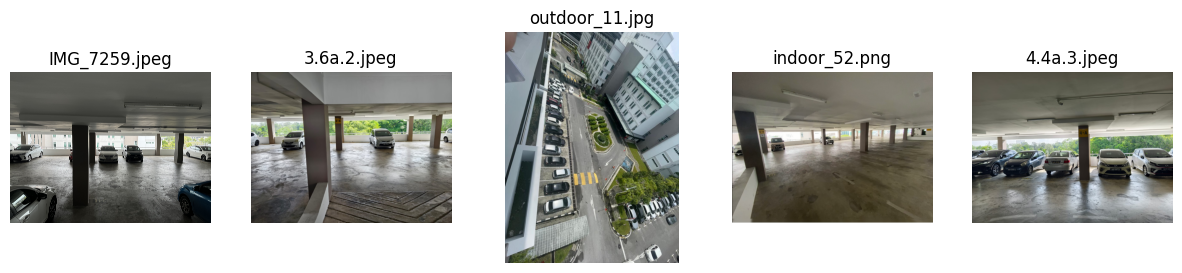

Contents of label file car2b_402.txt:
0 0.824875 0.739333 0.348250 0.503333
0 0.145000 0.664833 0.289500 0.463667
0 0.835625 0.376333 0.118250 0.078667
0 0.670375 0.373333 0.090250 0.083333
0 0.323125 0.730500 0.549250 0.519667
0 0.090375 0.366833 0.111250 0.066333
0 0.179625 0.363833 0.128750 0.079000
0 0.040875 0.365167 0.081750 0.069667
0 0.922250 0.369000 0.155500 0.096000
0 0.307125 0.374167 0.034750 0.065000
0 0.511375 0.369500 0.052250 0.073000



In [23]:
import os
from glob import glob
import random
import matplotlib.pyplot as plt
from PIL import Image

# Paths to split directories
split_dir = os.path.join('data', 'split')
images_dir = os.path.join(split_dir, 'images')
labels_dir = os.path.join(split_dir, 'labels')

# Count images and labels in each split
splits = ['train', 'val', 'test']
for split in splits:
    imgs = glob(os.path.join(images_dir, split, '*'))
    lbls = glob(os.path.join(labels_dir, split, '*'))
    print(f"{split.capitalize()} - Images: {len(imgs)}, Labels: {len(lbls)}")

# Show a few random images from the train split
sample_imgs = glob(os.path.join(images_dir, 'train', '*'))
if sample_imgs:
    sample_imgs = random.sample(sample_imgs, min(5, len(sample_imgs)))
    plt.figure(figsize=(15, 3))
    for i, img_path in enumerate(sample_imgs):
        img = Image.open(img_path)
        plt.subplot(1, len(sample_imgs), i+1)
        plt.imshow(img)
        plt.title(os.path.basename(img_path))
        plt.axis('off')
    plt.show()
else:
    print('No images found in train split.')

# Show the contents of a random label file from train split
sample_lbls = glob(os.path.join(labels_dir, 'train', '*'))
if sample_lbls:
    lbl_path = random.choice(sample_lbls)
    print(f'Contents of label file {os.path.basename(lbl_path)}:')
    with open(lbl_path, 'r') as f:
        print(f.read())
else:
    print('No label files found in train split.')

As shown the data contains images of indoor and outdoor parking lots. The dataset is already in the YOLO format.

Each image have a text file containing the labels.
1. Understand YOLO Label Format

Each .txt file corresponds to one image, and contains lines like:

    <class_id> <x_center> <y_center> <width> <height>


class_id: integer (0 : occupied  --  1 : empty).

x_center, y_center, width, height: normalized values between 0 and 1, relative to image width/height.